# Task 10: Time Series Data Analysis

## Objective
Analyze Apple stock market data using Time Series Analysis techniques.

### Tasks Covered
- Data Loading
- Data Exploration
- Stationarity Check
- Moving Average Analysis
- Seasonal Decomposition
- Forecasting Future Values

### Tools Used
- Python
- Pandas
- Matplotlib
- Statsmodels

# Import required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

import warnings
warnings.filterwarnings('ignore')

# Step 1: Load the Dataset

In this step, we load the Apple stock dataset into a Pandas DataFrame.

In [3]:
df = pd.read_csv("finance-charts-apple.csv")

df.head()

,Date,AAPL.Open,AAPL.High,AAPL.Low,AAPL.Close,AAPL.Volume,AAPL.Adjusted,dn,mavg,up,direction
0,2015-02-17,127.489998,128.880005,126.919998,127.830002,63152400,122.905254,106.741052,117.927667,129.114281,Increasing
1,2015-02-18,127.629997,128.779999,127.449997,128.720001,44891700,123.760965,107.842423,118.940333,130.038244,Increasing
2,2015-02-19,128.479996,129.029999,128.330002,128.449997,37362400,123.501363,108.894245,119.889167,130.884089,Decreasing
3,2015-02-20,128.619995,129.500000,128.050003,129.500000,48948400,124.510914,109.785449,120.763500,131.741551,Increasing
4,2015-02-23,130.020004,133.000000,129.660004,133.000000,70974100,127.876074,110.372516,121.720167,133.067817,Increasing


# Step 2: Explore the Dataset

Let's check:
- Number of rows and columns
- Data types
- Missing values

In [4]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

Shape of Dataset:
(506, 11)

Columns:
Index(['Date', 'AAPL.Open', 'AAPL.High', 'AAPL.Low', 'AAPL.Close',
       'AAPL.Volume', 'AAPL.Adjusted', 'dn', 'mavg', 'up', 'direction'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           506 non-null    str    
 1   AAPL.Open      506 non-null    float64
 2   AAPL.High      506 non-null    float64
 3   AAPL.Low       506 non-null    float64
 4   AAPL.Close     506 non-null    float64
 5   AAPL.Volume    506 non-null    int64  
 6   AAPL.Adjusted  506 non-null    float64
 7   dn             506 non-null    float64
 8   mavg           506 non-null    float64
 9   up             506 non-null    float64
 10  direction      506 non-null    str    
dtypes: float64(8), int64(1), str(2)
memory usage: 43.6 KB
None


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Date             0
AAPL.Open        0
AAPL.High        0
AAPL.Low         0
AAPL.Close       0
AAPL.Volume      0
AAPL.Adjusted    0
dn               0
mavg             0
up               0
direction        0
dtype: int64


# Step 3: Select Required Columns

For Time Series Analysis, we only need:
- Date
- Closing Price

In [6]:
df = df[['Date','AAPL.Close']]

df.rename(columns={'AAPL.Close':'Close'}, inplace=True)

df.head()

,Date,Close
0,2015-02-17,127.830002
1,2015-02-18,128.720001
2,2015-02-19,128.449997
3,2015-02-20,129.500000
4,2015-02-23,133.000000


# Step 4: Convert Date Column

Convert Date into datetime format and make it the index.

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

df.head()

,Close
Date,
2015-02-17,127.830002
2015-02-18,128.720001
2015-02-19,128.449997
2015-02-20,129.500000
2015-02-23,133.000000


# Step 5: Visualize Stock Closing Price

This graph shows how Apple's stock price changed over time.

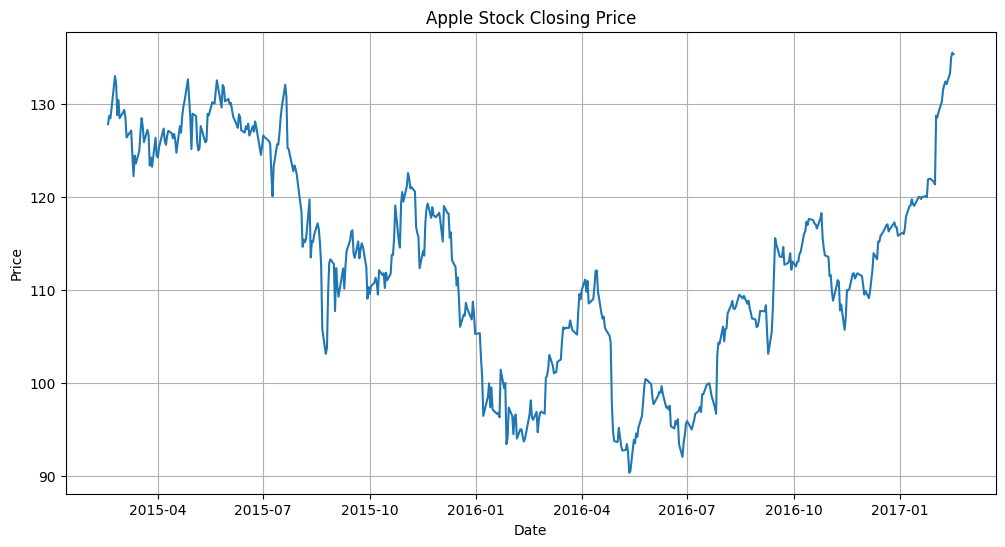

In [8]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'])

plt.title("Apple Stock Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.grid(True)

plt.show()

# Step 6: Stationarity Check

We use the Augmented Dickey-Fuller (ADF) Test.

### Interpretation:
- p-value < 0.05 → Stationary Data
- p-value > 0.05 → Non-Stationary Data

In [9]:
result = adfuller(df['Close'])

print("ADF Statistic:", result[0])

print("P-Value:", result[1])

if result[1] < 0.05:
    print("Data is Stationary")
else:
    print("Data is Non-Stationary")

ADF Statistic: -1.3724708211271162
P-Value: 0.5954005034777841
Data is Non-Stationary


# Step 7: Calculate Moving Averages

Moving averages help smooth fluctuations and identify trends.

We calculate:
- 7-Day Moving Average
- 30-Day Moving Average

In [10]:
df['MA_7'] = df['Close'].rolling(window=7).mean()

df['MA_30'] = df['Close'].rolling(window=30).mean()

df.head()

,Close,MA_7,MA_30
Date,,,
2015-02-17,127.830002,NaN,NaN
2015-02-18,128.720001,NaN,NaN
2015-02-19,128.449997,NaN,NaN
2015-02-20,129.500000,NaN,NaN
2015-02-23,133.000000,NaN,NaN


# Step 8: Plot Moving Averages

Compare actual stock prices with moving averages.

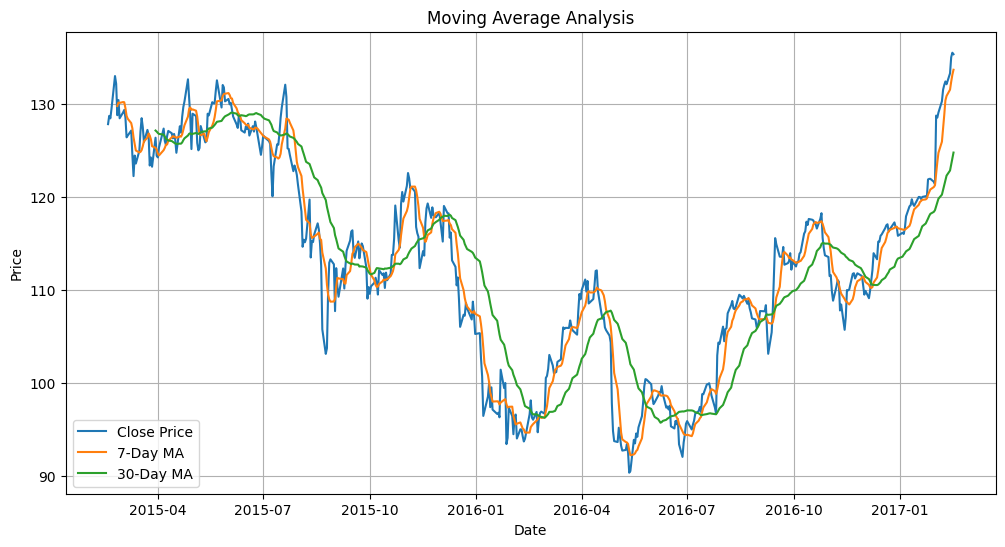

In [11]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'], label='Close Price')

plt.plot(df['MA_7'], label='7-Day MA')

plt.plot(df['MA_30'], label='30-Day MA')

plt.title("Moving Average Analysis")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

# Step 9: Seasonal Decomposition

Seasonal decomposition breaks the series into:

- Trend
- Seasonal Component
- Residual Component

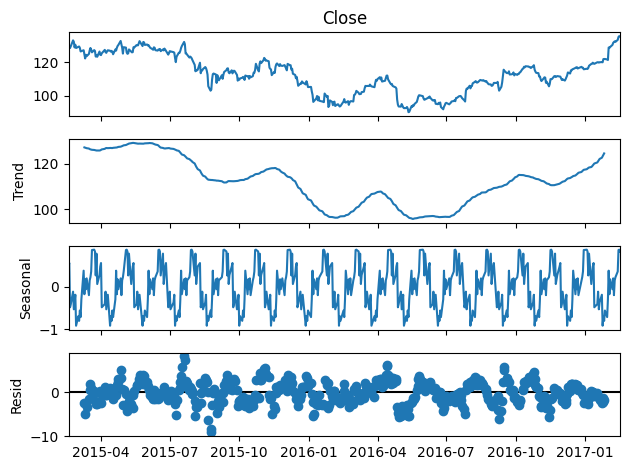

In [12]:
decomposition = seasonal_decompose(
    df['Close'],
    model='additive',
    period=30
)

decomposition.plot()

plt.show()

# Step 10: Build Forecasting Model

We use Exponential Smoothing for forecasting future stock prices.

In [13]:
model = ExponentialSmoothing(
    df['Close'],
    trend='add'
)

fit_model = model.fit()

# Step 11: Forecast Next 30 Days

Predict stock prices for the next 30 days.

In [14]:
forecast = fit_model.forecast(30)

forecast

506    135.364897
507    135.379788
508    135.394679
509    135.409570
510    135.424461
511    135.439352
512    135.454243
513    135.469134
514    135.484025
515    135.498916
516    135.513807
517    135.528698
518    135.543589
519    135.558480
520    135.573371
521    135.588262
522    135.603153
523    135.618043
524    135.632934
525    135.647825
526    135.662716
527    135.677607
528    135.692498
529    135.707389
530    135.722280
531    135.737171
532    135.752062
533    135.766953
534    135.781844
535    135.796735
dtype: float64

# Step 12: Visualize Forecast

Compare actual stock prices with forecasted values.

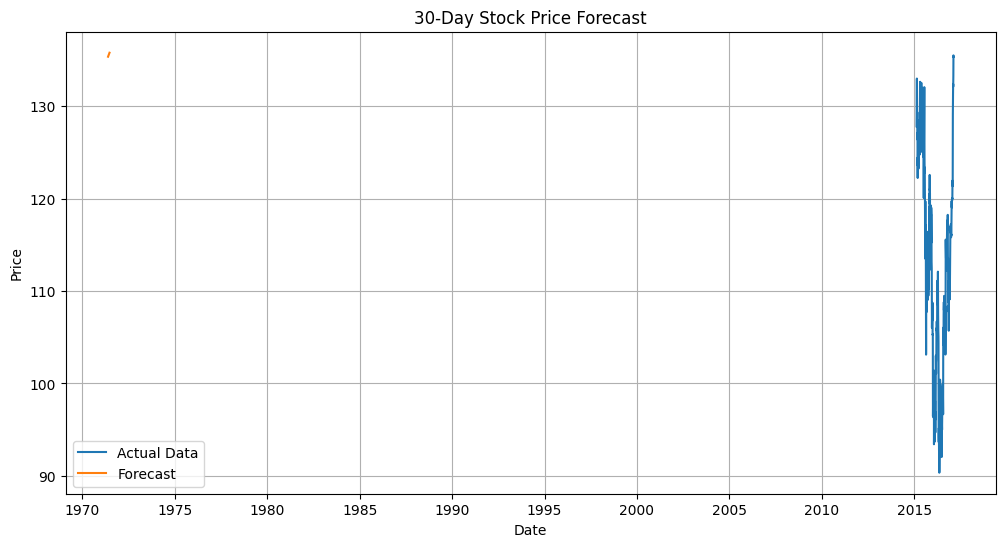

In [15]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'], label='Actual Data')

plt.plot(forecast.index,
         forecast,
         label='Forecast')

plt.title("30-Day Stock Price Forecast")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

# Step 13: Save Forecast Results

Store forecasted values in a CSV file.

In [16]:
forecast_df = pd.DataFrame({
    "Forecasted_Close_Price": forecast
})

forecast_df.to_csv("forecast_output.csv")

print("Forecast file saved successfully.")

Forecast file saved successfully.


# Conclusion

In this project:

- Loaded Apple Stock Market Dataset
- Performed Time Series Analysis
- Checked Stationarity using ADF Test
- Calculated Moving Averages
- Identified Trend and Seasonality
- Forecasted Future Stock Prices

Time Series Analysis helps in understanding historical patterns and predicting future values.